This file plots results obtained at 1MHz frame rate 

In [1]:
from hsflfm.util import load_dictionary, save_dictionary, MetadataManager, load_video
from hsflfm.processing import StrikeProcessor 
from hsflfm.analysis import BulkAnalyzer, ResultManager, ResultPlotter, get_strike_center, sort_by_camera

import os 
from tqdm import tqdm 
import numpy as np 
from scipy.ndimage import gaussian_filter1d 
from matplotlib import pyplot as plt
from hsflfm.config import home_directory
import pandas as pd 
import torch

import matplotlib 

In [2]:
def get_save_filename(specimen_number, strike_number, save_folder):
    spec_folder = save_folder + f"/{specimen_number}"
    filename = spec_folder + f"/strike_{int(strike_number)}_results.json"
    return filename
    
result_folder = home_directory + '/results/megahertz_video_dataset'

In [3]:
specimen = "20251031_OB_2"
strike_number = 2
mm = MetadataManager(specimen) 

filename = get_save_filename(specimen, strike_number, result_folder)
assert os.path.exists(filename) 
results = load_dictionary(filename) 

rm = ResultManager(results) 
errors = rm.error_scores 
good_indices = np.where(errors < 0.0015)[0]

plotter = ResultPlotter(results, good_indices=good_indices)  

0it [00:00, ?it/s]


Text(0.5, 0.98, '3D exoskeleton displacement, \n at t=180 us after start of video')

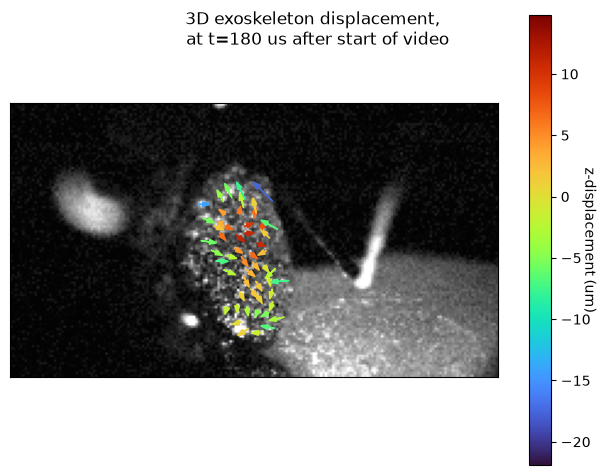

In [18]:
strike_center = plotter.result_manager.strike_center_index()
frame_rate = plotter.data_manager.get_frame_rate(strike_number) 
frame = plotter.get_arrow_video(crop_buffer=None, frames=[strike_center+20],
                                show_coord_frame=False, clim=(20, 100))

t = (strike_center + 20) / frame_rate * 1e6
frame.suptitle(f"3D exoskeleton displacement, \n at t={t:.0f} us after start of video")

Text(0.5, 0.98, 'Optical flow for tracked points')

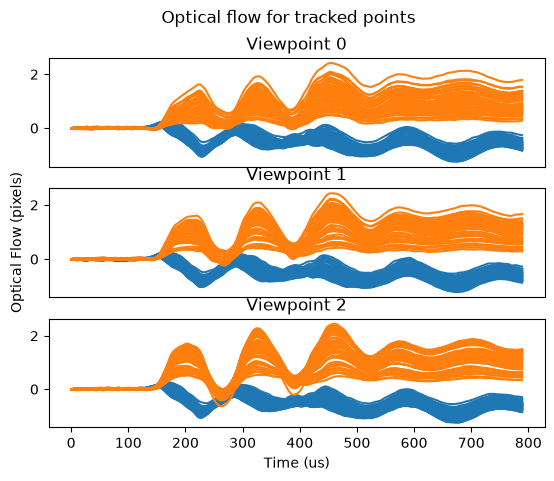

In [24]:
flow = np.asarray(results["flow_vectors"]) 
errors = np.asarray(results["error_metric"])
flow = flow[errors < 0.0015, :, :]#120:300]
time = np.arange(flow.shape[-1])
colors = plt.rcParams['axes.prop_cycle'].by_key()["color"] 

fig, axes = plt.subplots(3, 1)
for i, ax in enumerate(axes):
    ax.plot(time, flow[:, 2 * i].T, color=colors[0])
    ax.plot(time, flow[:, 2 * i + 1].T, color=colors[1])
    if i != 2:
        ax.set_xticks([])
    ax.set_title(f"Viewpoint {i}")

axes[-1].set_xlabel("Time (us)")
axes[1].set_ylabel("Optical Flow (pixels)")

fig.suptitle("Optical flow for tracked points")

Text(0.5, 0.98, 'Absolute 3D displacement of tracked points')

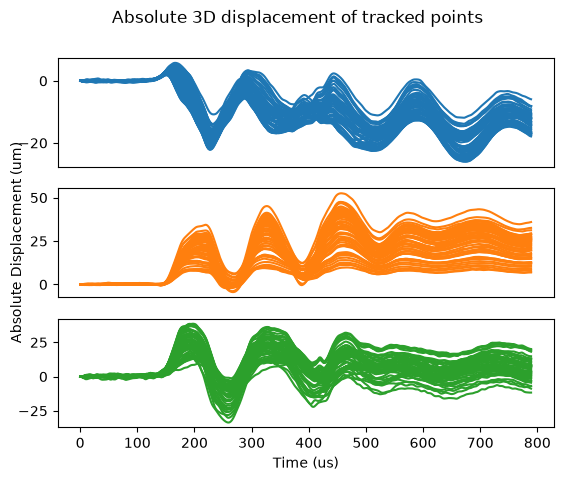

In [20]:
flow = np.asarray(results["camera_point_displacements"]) 
errors = np.asarray(results["error_metric"])
flow = flow[errors < 0.0015, :, :]#120:300]
time = np.arange(flow.shape[1])
colors = plt.rcParams['axes.prop_cycle'].by_key()["color"] 

fig, axes = plt.subplots(3, 1)
for i, ax in enumerate(axes):
    ax.plot(time, flow[:, :, i].T * 1e3, color=colors[i])
    if i != 2:
        ax.set_xticks([])

axes[-1].set_xlabel("Time (us)")
axes[1].set_ylabel("Absolute Displacement (um)")

fig.suptitle("Absolute 3D displacement of tracked points")

Text(0.5, 0.98, 'Relative 3D displacement of tracked points')

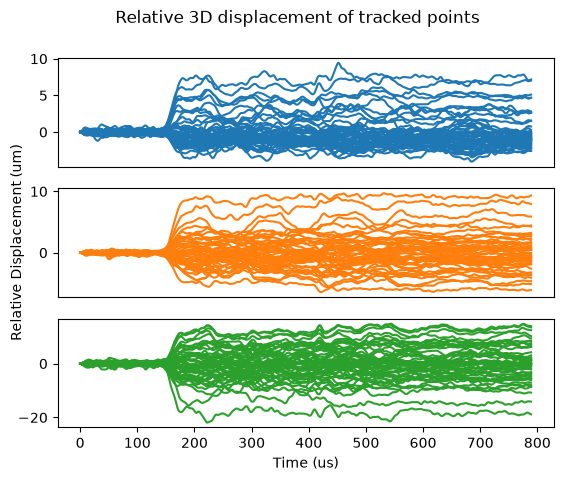

In [22]:
flow = np.asarray(results["rel_displacements"]) 
errors = np.asarray(results["error_metric"])
flow = flow[errors < 0.0015, :, :]#120:300]
time = np.arange(flow.shape[1])
colors = plt.rcParams['axes.prop_cycle'].by_key()["color"] 

fig, axes = plt.subplots(3, 1)
for i, ax in enumerate(axes):
    ax.plot(time, flow[:, :, i].T * 1e3, color=colors[i])
    if i != 2:
        ax.set_xticks([])

axes[-1].set_xlabel("Time (us)")
axes[1].set_ylabel("Relative Displacement (um)")

fig.suptitle("Relative 3D displacement of tracked points")